In [8]:
import sys
sys.path.append('../src')
from backgammon_env import *

import numpy as np
import matplotlib.pyplot as plt

env = BackgammonEnv()
print("Import réussi ✓ — board initial :", env.board)

Import réussi ✓ — board initial : [ 1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. -1. -1. -1.]


In [9]:
def encoder_case(nb_pions):
    unites = [0, 0, 0]
    for i in range(min(nb_pions, 3)):
        unites[i] = 1
    return unites


def encoder_etat(env):
    inputs = []
    for case in range(24):
        valeur = env.board[case]
        nb_blanc = int(valeur) if valeur > 0 else 0
        nb_noir = int(-valeur) if valeur < 0 else 0
        inputs.extend(encoder_case(nb_blanc))
        inputs.extend(encoder_case(nb_noir))
    
    inputs.append(env.bar_blanc / env.n_pions)
    inputs.append(env.bar_noir / env.n_pions)
    inputs.append(env.sortis_blanc / env.n_pions)
    inputs.append(env.sortis_noir / env.n_pions)
    inputs.append(1.0 if env.joueur_actuel == "blanc" else 0.0)
    
    return np.array(inputs)


# Test immediat
env = BackgammonEnv()
v = encoder_etat(env)
assert len(v) == 149, f"Taille incorrecte : {len(v)}"
print("Encodage OK — taille :", len(v))

Encodage OK — taille : 149


In [10]:
class ReseauValeur:
    """MLP 149 -> n_caches -> 1. Sortie = proba de victoire des Blancs."""
    
    def __init__(self, n_inputs=149, n_caches=40, alpha=0.01):
        self.alpha = alpha
        self.W1 = np.random.randn(n_inputs, n_caches) * 0.1
        self.b1 = np.zeros(n_caches)
        self.W2 = np.random.randn(n_caches, 1) * 0.1
        self.b2 = np.zeros(1)
    
    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))
    
    def forward(self, x):
        self.x = x
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2[0]
    
    def backward(self, td_error):
        delta2 = td_error * self.a2 * (1 - self.a2)
        dW2 = np.outer(self.a1, delta2)
        db2 = delta2
        delta1 = (delta2 @ self.W2.T) * self.a1 * (1 - self.a1)
        dW1 = np.outer(self.x, delta1)
        db1 = delta1
        
        self.W1 += self.alpha * dW1
        self.b1 += self.alpha * db1.flatten()
        self.W2 += self.alpha * dW2
        self.b2 += self.alpha * db2.flatten()
    
    def copier_poids(self):
        return (self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy())
    
    def restaurer_poids(self, poids):
        self.W1, self.b1, self.W2, self.b2 = [p.copy() for p in poids]

In [11]:
def simuler_sequence(env, seq):
    """
    Applique une sequence sur une COPIE legere de l'etat, sans recreer
    un environnement complet (optimisation vs version precedente).
    Retourne un objet etat minimal compatible avec encoder_etat.
    """
    class EtatSimule:
        pass
    
    sim = EtatSimule()
    sim.board = env.board.copy()
    sim.bar_blanc = env.bar_blanc
    sim.bar_noir = env.bar_noir
    sim.sortis_blanc = env.sortis_blanc
    sim.sortis_noir = env.sortis_noir
    sim.joueur_actuel = env.joueur_actuel
    sim.n_pions = env.n_pions
    
    s = 1 if env.joueur_actuel == "blanc" else -1
    
    for (depart, arrivee, de) in seq:
        if depart == -1:
            if s == 1: sim.bar_blanc -= 1
            else: sim.bar_noir -= 1
        else:
            sim.board[depart] -= s
        
        if arrivee == -1:
            if s == 1: sim.sortis_blanc += 1
            else: sim.sortis_noir += 1
            continue
        
        if sim.board[arrivee] * s == -1:
            sim.board[arrivee] = 0
            if s == 1: sim.bar_noir += 1
            else: sim.bar_blanc += 1
        
        sim.board[arrivee] += s
    
    return sim


def choisir_meilleure_sequence(env, sequences, reseau):
    """Blanc maximise V, Noir minimise V."""
    meilleure_seq = None
    meilleure_valeur = None
    joueur = env.joueur_actuel
    
    for seq in sequences:
        sim = simuler_sequence(env, seq)
        valeur = reseau.forward(encoder_etat(sim))
        
        if meilleure_valeur is None:
            meilleure_seq, meilleure_valeur = seq, valeur
        elif joueur == "blanc" and valeur > meilleure_valeur:
            meilleure_seq, meilleure_valeur = seq, valeur
        elif joueur == "noir" and valeur < meilleure_valeur:
            meilleure_seq, meilleure_valeur = seq, valeur
    
    return meilleure_seq

In [12]:
def evaluer_contre_random(reseau, n_parties=100):
    victoires = 0
    for _ in range(n_parties):
        env = BackgammonEnv()
        env.reset()
        for tour in range(500):
            des = lancer_des()
            sequences = env.coups_disponibles(des)
            if sequences:
                if env.joueur_actuel == "blanc":
                    seq = choisir_meilleure_sequence(env, sequences, reseau)
                else:
                    seq = sequences[np.random.randint(len(sequences))]
                for (depart, arrivee, de) in seq:
                    env.jouer_coup(depart, arrivee)
            gagnant = env.partie_terminee()
            if gagnant:
                if gagnant == "blanc":
                    victoires += 1
                break
            env.changer_joueur()
    return victoires / n_parties

In [13]:
def entrainer(n_parties=4000, alpha_debut=0.02, alpha_fin=0.002,
              epsilon_debut=0.15, epsilon_fin=0.01, eval_tous_les=500):
    """
    Entrainement TD(0) self-play avec :
    - alpha et epsilon decroissants (stabilite)
    - evaluation periodique du winrate
    - early stopping : restauration du meilleur reseau a la fin
    """
    reseau = ReseauValeur(n_inputs=149, n_caches=40, alpha=alpha_debut)
    historique_winrate = []
    meilleur_winrate = 0.0
    meilleurs_poids = reseau.copier_poids()
    
    for partie in range(n_parties):
        progression = partie / n_parties
        epsilon = epsilon_debut + (epsilon_fin - epsilon_debut) * progression
        reseau.alpha = alpha_debut + (alpha_fin - alpha_debut) * progression
        
        env = BackgammonEnv()
        env.reset()
        etat_precedent = encoder_etat(env)
        V_precedent = reseau.forward(etat_precedent)
        
        for tour in range(500):
            des = lancer_des()
            sequences = env.coups_disponibles(des)
            
            if sequences:
                if np.random.rand() < epsilon:
                    seq = sequences[np.random.randint(len(sequences))]
                else:
                    seq = choisir_meilleure_sequence(env, sequences, reseau)
                for (depart, arrivee, de) in seq:
                    env.jouer_coup(depart, arrivee)
            
            gagnant = env.partie_terminee()
            
            if gagnant:
                reward = 1.0 if gagnant == "blanc" else 0.0
                td_error = reward - V_precedent
                reseau.forward(etat_precedent)
                reseau.backward(td_error)
                break
            
            env.changer_joueur()
            etat_nouveau = encoder_etat(env)
            V_nouveau = reseau.forward(etat_nouveau)
            td_error = V_nouveau - V_precedent
            reseau.forward(etat_precedent)
            reseau.backward(td_error)
            etat_precedent = etat_nouveau
            V_precedent = V_nouveau
        
        # Evaluation periodique + early stopping
        if (partie + 1) % eval_tous_les == 0:
            winrate = evaluer_contre_random(reseau, n_parties=100)
            historique_winrate.append(winrate)
            
            marqueur = ""
            if winrate > meilleur_winrate:
                meilleur_winrate = winrate
                meilleurs_poids = reseau.copier_poids()
                marqueur = " *** nouveau record ***"
            
            print(f"Partie {partie + 1}/{n_parties} — alpha {reseau.alpha:.4f} — "
                  f"epsilon {epsilon:.3f} — winrate {winrate:.1%}{marqueur}")
    
    reseau.restaurer_poids(meilleurs_poids)
    print(f"\nMeilleur réseau restauré — winrate : {meilleur_winrate:.1%}")
    
    return reseau, historique_winrate, meilleur_winrate

Partie 500/10000 — alpha 0.0191 — epsilon 0.143 — winrate 58.0% *** nouveau record ***
Partie 1000/10000 — alpha 0.0182 — epsilon 0.136 — winrate 53.0%
Partie 1500/10000 — alpha 0.0173 — epsilon 0.129 — winrate 58.0%
Partie 2000/10000 — alpha 0.0164 — epsilon 0.122 — winrate 65.0% *** nouveau record ***
Partie 2500/10000 — alpha 0.0155 — epsilon 0.115 — winrate 62.0%
Partie 3000/10000 — alpha 0.0146 — epsilon 0.108 — winrate 56.0%
Partie 3500/10000 — alpha 0.0137 — epsilon 0.101 — winrate 56.0%
Partie 4000/10000 — alpha 0.0128 — epsilon 0.094 — winrate 64.0%
Partie 4500/10000 — alpha 0.0119 — epsilon 0.087 — winrate 52.0%
Partie 5000/10000 — alpha 0.0110 — epsilon 0.080 — winrate 63.0%
Partie 5500/10000 — alpha 0.0101 — epsilon 0.073 — winrate 55.0%
Partie 6000/10000 — alpha 0.0092 — epsilon 0.066 — winrate 50.0%
Partie 6500/10000 — alpha 0.0083 — epsilon 0.059 — winrate 61.0%
Partie 7000/10000 — alpha 0.0074 — epsilon 0.052 — winrate 54.0%
Partie 7500/10000 — alpha 0.0065 — epsilon 0.

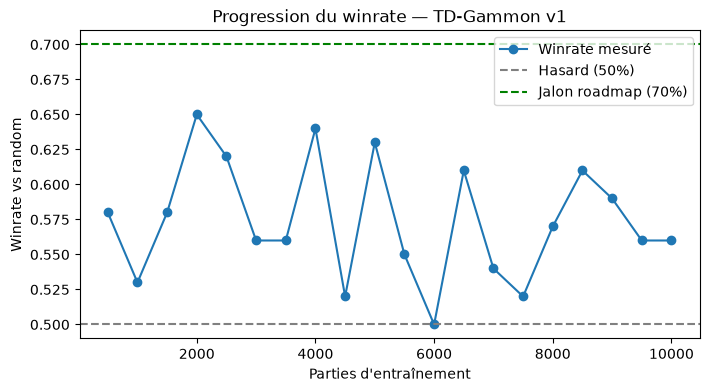

In [14]:
# ENTRAINEMENT + GRAPHIQUE dans la meme cellule : toujours synchronises
reseau, winrates, record = entrainer(n_parties=10000, eval_tous_les=500)

# Evaluation finale plus precise du meilleur reseau (500 parties)
winrate_final = evaluer_contre_random(reseau, n_parties=500)
print(f"\nWinrate final (500 parties d'évaluation) : {winrate_final:.1%}")

# Graphique — axe x calcule automatiquement depuis la taille reelle de winrates
x_axis = [500 * (i + 1) for i in range(len(winrates))]

plt.figure(figsize=(8, 4))
plt.plot(x_axis, winrates, marker='o', label='Winrate mesuré')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Hasard (50%)')
plt.axhline(y=0.7, color='green', linestyle='--', label='Jalon roadmap (70%)')
plt.xlabel("Parties d'entraînement")
plt.ylabel("Winrate vs random")
plt.title("Progression du winrate — TD-Gammon v1")
plt.legend()
plt.show()